# **Title Here**


## **CSMODEL S10A, Group 4: Balikbayan Babes**
**Co**, Alphonso Rian; **Guarin**, Raine Louise; **Maravilla**, Sofia; **Melanio**, Marion Zane; **Pasigan**, Maria Elisa

## **ABSTRACT**

## **DATASET DESCRIPTION**

The dataset International Social Survey Programme: Social Inequality I-V Cumulation explores the different social backgrounds from different countries that determine the personal success in society. Such factors are family, race, talents, skills, ambition, religion, and education.  

The population was sampled varyingly from country to country from simple random sampling to multistage sampling, producing results to over 157446 instances. To collect numeric data, many of the data collectors from multiple countries used self-administered closed-ended questionnaires (paper and web-based), interviews (computer-assisted and paper-and-pencil face-to-face, web-based, telephone) data collection instruments. Researchers made sure sampling reflected the country's population as expressed by its WEIGHT variable. It is notable that populations vary from country to country.

Each of the 157446 instances are analyzed individually, meaning, each row represents a person and their personal background. The 106 columns represent the attributes the person should have defined by the research, and the questions involved in the survey/interview. Atrributes stored are used for identification (GESIS archive no., DOI, ID of the respondent, year, country), personal information (age, sex, education, occupation), and the different factors that affected their daily lives (n. members of the household, voting history, supported political parties).

## **DATA CLEANING AND PREPROCESSING**

The code below involves fixing the format for all involved columns, and grouping values to lessen categories. Since the data type was categorical for all columns, excluding cumu_id, they were all fixed to contain strings for ease of using replace and loc. Missing values were grouped together with the category "No answer". No values were dropped.

In [1]:
import pandas as pd
import math as m
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

dataframe = pd.read_stata("social_inequality.dta")

In [2]:
cols_to_drop = [f"v{i}" for i in range(1,72)]
new_df = dataframe.drop(columns=cols_to_drop)
cols_to_drop = ['version', 'doi', 'studyno', 'caseid', 'c_sample', 'c_sample_year', 'PRTY_LR1', 'PRTY_LR2', 'VOTE_LE', 'VOTE_LR', 'WEIGHT', 'COHAB',
                'EDUCYRS', 'ISCO88', 'SELFEMP', 'WRKSUP', 'UNION', 'SPMAINST', 'SPISCO88', 'SPSELFEM', 'CHILDHH', 'ATTEND', 'WRKHRS']
new_df = new_df.drop(columns=cols_to_drop)

In [3]:
new_df['year'] = new_df['year'].str.extract(r'^(\d{4})')
new_df['year'].value_counts()

year
2009    44578
2019    42441
1999    31181
1992    23900
1987    15346
Name: count, dtype: int64

In [4]:
new_df['country'] = new_df['country'].astype(str)
new_df['country'] = new_df['country'].str.extract(r'\.\s*([A-Z]{2})-')
new_df['country'].value_counts()

country
DE    8940
AU    8131
PL    7971
PH    7850
US    7542
RU    6888
FR    6304
HU    6074
ZA    6032
GB    5764
CZ    5641
NO    5375
AT    5276
CH    5258
SE    4672
NZ    4492
CL    4382
BG    4380
IT    4322
SI    4284
JP    4094
TW    3952
IL    3602
SK    2663
DK    2556
ES    2426
HR    2201
IS    2174
LV    2169
PT    2144
VE    2088
LT    2073
CA    1976
CY    1904
FI    1846
Name: count, dtype: int64

In [5]:
new_df['SEX'] = new_df['SEX'].astype(str)
new_df['SEX'] = new_df['SEX'].replace({
    '1. Male': 'Male',
    '2. Female': 'Female',
    '-9. No Answer, refused': 'No answer'
})
new_df.dropna(subset=['SEX'])
new_df['SEX'].value_counts()

SEX
Female       83852
Male         73351
No answer      243
Name: count, dtype: int64

In [6]:
pd.set_option('display.max_rows', None)
new_df['AGE'] = new_df['AGE'].astype(str)
new_df['AGE'] = new_df["AGE"].replace({
    "-9. No Answer, Don't know, refused": 'No answer',
    "15. 15 Years": '15',
    '105. 105 Years': '105'
})
new_df = new_df.dropna(subset=['AGE'])
new_df['AGE'] = pd.to_numeric(new_df['AGE'], errors='coerce')
new_df['AGE_GROUP'] = pd.cut(
    new_df['AGE'],
    bins=[0, 17, 24, 44, 64, 150],
    labels=[
        'Minor',
        'Young Adult',
        'Adult',
        'Middle-aged Adult',
        'Senior Citizen'
    ]
)

new_df['AGE_GROUP'].value_counts()

AGE_GROUP
Adult                57358
Middle-aged Adult    53785
Senior Citizen       28516
Young Adult          16350
Minor                  647
Name: count, dtype: int64

In [7]:
new_df['MARITAL'] = new_df['MARITAL'].astype(str)
new_df['MARITAL'] = new_df["MARITAL"].replace({
    "1. Married, Civil Partnership": "Married",
    "5. Never married, single": 'Single',
})
new_df.loc[
    new_df['MARITAL'].isin(
        ['2. Widowed', '3. Divorced', '4. Separated (married but sep./not living w legal spouse)']
    ),
    'MARITAL'
] = 'Previously Married'
new_df.loc[
    new_df['MARITAL'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer, refused', '-7. Refused']
    ),
    'MARITAL'
] = 'No answer'
new_df['MARITAL'].value_counts()

MARITAL
Married               87868
Single                37771
Previously Married    26490
No answer              5317
Name: count, dtype: int64

In [8]:
new_df['DEGREE'] = new_df['DEGREE'].astype(str)
new_df['DEGREE'] = new_df['DEGREE'].replace({
    '3. Higher secondary completed': 'Higher secondary',
    '2. Above lowest qualification': 'Above lowest',
    '5. University degree completed, graduate studies': 'Graduate studies',
    '1. Lowest formal qualification': 'Lowest formal',
    '4. Above higher secondary level': 'Above higher secondary',
    '0. No formal qualification': 'No formal qualification',
    "-9. NA, DK, can't choose, other": 'No answer'
})
new_df['DEGREE'].value_counts()

DEGREE
Higher secondary           39569
Above lowest               34718
Graduate studies           30910
Lowest formal              21820
Above higher secondary     19602
No formal qualification     9389
No answer                   1438
Name: count, dtype: int64

In [9]:
new_df['MAINSTAT'] = new_df['MAINSTAT'].astype(str)
new_df['MAINSTAT'] = new_df['MAINSTAT'].replace({
    '1. In paid work': 'Employed',
    '5. Retired': 'Retired',
    '2. Unemployed and looking for a job': 'Unemployed',
    '-4. NAP, never had paid work': 'Unemployed',
    '6. Domestic work': 'Domestic work',
    '3. In education / Apprentice or trainee': 'Apprentice or trainee',
    '4. Permanently sick or disabled': 'Sick or disabled'
})
new_df.loc[
    new_df['MAINSTAT'].isin(
        ['8. Other', '7. In compulsory military service or community service']
    ),
    'MAINSTAT'
] = 'Other'
new_df.loc[
    new_df['MAINSTAT'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer', "-8. Don't know", '-7. Refused']
    ),
    'MAINSTAT'
] = 'No answer'
new_df['MAINSTAT'].value_counts()

MAINSTAT
Employed                 84304
Retired                  29316
Domestic work            10260
Unemployed               10056
Other                     7358
Apprentice or trainee     7338
No answer                 6262
Sick or disabled          2552
Name: count, dtype: int64

In [10]:
new_df['HOMPOP'] = new_df['HOMPOP'].replace({
    '1. 1 person': '1',
    '-1. Variable not available for this country in this module': 'No answer',
    '-9. No Answer, refused': 'No answer',
    '-4. NAP, not a private household': 'No answer',
    '44. 44 persons': '44'
})
new_df['HOMPOP'] = pd.to_numeric(new_df['HOMPOP'], errors='coerce').astype('Int64')
new_df['HOMPOP'].value_counts()

C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\4214904534.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  new_df['HOMPOP'] = new_df['HOMPOP'].replace({


HOMPOP
2     43377
4     29526
3     28625
1     23218
5     13596
6      5990
7      2533
8      1282
9       661
10      333
11      187
12      121
13       57
14       28
15       18
16       13
18       10
17        9
19        5
25        3
20        3
23        2
22        2
44        1
40        1
Name: count, dtype: Int64

In [11]:
new_df['RELIGGRP'] = new_df['RELIGGRP'].astype(str)
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['2. Roman Catholic', '3. Protestant', '4. Christian Orthodox', '9. Other Christian Religions', '96. No (Christian) denomination given']
    ),
    'RELIGGRP'
] = 'Christian'
new_df['RELIGGRP'] = new_df['RELIGGRP'].replace({
    '1. No religion': 'No religion',
    '5. Jewish': 'Jewish',
    '6. Islam': 'Islam',
    '7. Buddhism': 'Buddhism'
})
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['10. Other Eastern/Asian Religions', '11. Other Religions', '8. Hinduism']
    ),
    'RELIGGRP'
] = 'Other'
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer, refused', "-8. Don't know", '-7. Refused']
    ),
    'RELIGGRP'
] = 'No answer'
new_df['RELIGGRP'].value_counts()

RELIGGRP
Christian      104299
No religion     31155
No answer        9656
Other            4017
Jewish           3373
Islam            2547
Buddhism         2399
Name: count, dtype: int64

In [12]:
new_df['TOPBOT'] = new_df['TOPBOT'].astype(str)
new_df['TOPBOT'] = new_df['TOPBOT'].replace({
    '1. Bottom, Lowest, 01': '1',
    '2. 02': '2',
    '3. 03': '3',
    '4. 04': '4',
    '5. 05': '5',
    '6. 06': '6',
    '7. 07': '7',
    '8. 08': '8',
    '9. 09': '9',
    '10. Top, Highest, 10': '10'
})
new_df.loc[
    new_df['TOPBOT'].isin(
        ['-9. No Answer', "-8. Don't know, can't choose", '-7. Refused']
    ),
    'TOPBOT'
] = 'No answer'

new_df['TOPBOT'] = new_df['TOPBOT'].replace({
    'No answer' : -1
})

new_df['TOPBOT'] = pd.to_numeric(new_df['TOPBOT'], errors='coerce')# 1. Kunin ang median ng TOPBOT habang hindi kasama ang -1
topbot_median = new_df[new_df['TOPBOT'] != -1]['TOPBOT'].median()

# 2. I-replace ang -1 gamit ang nakuha nating median value
new_df['TOPBOT'] = new_df['TOPBOT'].replace(-1, topbot_median)

# 3. Siguraduhing integer (buong numero) pa rin ang column
new_df['TOPBOT'] = new_df['TOPBOT'].astype(int)

# 4. Check mo ulit, dapat wala na ang -1 at nadagdag na sila sa median class!
print(new_df['TOPBOT'].value_counts())



TOPBOT
6     37669
5     37348
4     21039
7     19607
3     15376
8      9552
2      7371
1      6240
9      1962
10     1282
Name: count, dtype: int64


In [13]:
new_df['INCOME'] = new_df['INCOME'].replace({
    '1. Low': 1,
    '2. Middle': 2,
    '3. High': 3,
    '-9. No Answer': -1,
    '-1. Variable not available for this country in this module': -1,
    '-7. Refused': -1,
    "-8. Don't know": -1
})


# 1. Kunin ang lahat ng index ng mga nag-"No Answer" (-1)
no_answer_indices = new_df[new_df['INCOME'] == -1].index

# 2. Compute kung ilan ang EXACT share ng bawat category (Yung logic mo)
income_div = m.floor(len(no_answer_indices) / 3)

# 3. I-slice nang eksaktong 'income_div' para sa bawat bracket
idx_for_low = no_answer_indices[0 : income_div]
idx_for_mid = no_answer_indices[income_div : income_div * 2]
idx_for_high = no_answer_indices[income_div * 2 : income_div * 3]

# 4. I-assign na sila sa new_df (Dito na sila pantay na madadagdag)
new_df.loc[idx_for_low, 'INCOME'] = 1
new_df.loc[idx_for_mid, 'INCOME'] = 2
new_df.loc[idx_for_high, 'INCOME'] = 3

# 5. Handling the Leftover (Yung 1 o 2 pirasong butal na sumobra sa floor division)
# Gagawin nating NaN ang natitirang -1 para i-drop na lang sila sa heatmap, 
# sa ganoong paraan, garantisadong PANTAY ang nadagdag sa 1, 2, at 3.
new_df['INCOME'] = new_df['INCOME'].replace(-1, np.nan)


# 6. Sanity Check: Tingnan ang bagong bilang
# Pwersahang i-convert ang INCOME column para maging NUMERO na pumapayag sa NaN (Int64)
new_df['INCOME'] = pd.to_numeric(new_df['INCOME'], errors='coerce').astype('Float64')

# 6. Sanity Check: Tingnan ang bagong bilang at info
print("Bagong distribution ng INCOME:")
print(new_df['INCOME'].value_counts(dropna=False)) # Para makita mo rin kung ilan ang naging NaN
new_df.info()


Bagong distribution ng INCOME:
INCOME
3.0     53163
1.0     52677
2.0     51605
<NA>        1
Name: count, dtype: Int64


C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\3938923754.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df['INCOME'] = new_df['INCOME'].replace({
C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\3938923754.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  new_df['INCOME'] = new_df['INCOME'].replace({
C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\3938923754.py:31: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157446 entries, 0 to 157445
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   cumu_id    157446 non-null  float64 
 1   year       157446 non-null  object  
 2   country    157446 non-null  object  
 3   SEX        157446 non-null  object  
 4   AGE        156656 non-null  float64 
 5   MARITAL    157446 non-null  object  
 6   DEGREE     157446 non-null  object  
 7   MAINSTAT   157446 non-null  object  
 8   HOMPOP     149601 non-null  Int64   
 9   RELIGGRP   157446 non-null  object  
 10  TOPBOT     157446 non-null  int64   
 11  INCOME     157445 non-null  Float64 
 12  AGE_GROUP  156656 non-null  category
dtypes: Float64(1), Int64(1), category(1), float64(2), int64(1), object(7)
memory usage: 14.9+ MB


## **RESEARCH QUESTION AND EXPLORATORY DATA ANALYSIS**

This project focuses on the different socio-demographic features (age, race, sex, marital status, religion, education, employment, household size) maximize the gap between an individual's objective income rank and their subjective social class identification. To achieve a clear answer, the following EDA must be addressed:
1. Is there a correlation between the features, income rank and social class identification?
2. What is the rank of the features when it comes to influence?
3. How does the magnitude and direction of the "income-class gap" vary across different socio-demographic intersections?



## **Gap Between Income and Social Class**

In [14]:
research_q1 = new_df[['TOPBOT', 'INCOME']]
research_q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157446 entries, 0 to 157445
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   TOPBOT  157446 non-null  int64  
 1   INCOME  157445 non-null  Float64
dtypes: Float64(1), int64(1)
memory usage: 2.6 MB


## Removing the rows with 'No answer' in both TOPBOT and INCOME

## Converting the INCOME data to numbers
1 = High Income

2 = Middle Income

3 = Low Income


In [15]:
research_q1.head(10)

,TOPBOT,INCOME
0,6,1.0
1,4,1.0
2,2,1.0
3,5,1.0
4,5,1.0
5,4,1.0
6,1,1.0
7,2,1.0
8,4,1.0
9,5,1.0


# Assistant
This error occurs because the variable `research_q1` has not been defined or created yet in your notebook. The `NameError` indicates that Python doesn't recognize this variable name.

**Possible reasons:**
1. You haven't created the `research_q1` variable yet
2. You haven't run the cell that creates this variable
3. The variable was created in a different notebook or session
4. There might be a typo in the variable name

**Common solutions:**
- Make sure you've run all the cells above that create or import `research_q1`
- Check if you need to load data from a file (CSV, Excel, etc.) into this variable
- Verify the variable name is spelled correctly

Would you like me to provide a corrected code example that shows how to properly create and use this variable?

## Converting the TOPBOT data to numbers

## Percentage between TOPBOT and INCOME per instance

Counting total TOPBOT and INCOME values

In [16]:
total_instances = research_q1.shape[0]
print(total_instances)

157446


## Calculating the gap between TOPBOT and INCOME

What is the ratio of all possible values in the INCOME column?

In [17]:
income_count_1s=research_q1['INCOME'].value_counts().get(1, 0)
income_count_2s=research_q1['INCOME'].value_counts().get(2, 0)
income_count_3s=research_q1['INCOME'].value_counts().get(3, 0)

income_percentages = pd.Series([income_count_1s, income_count_2s, income_count_3s])
print(income_percentages)

0    52677
1    51605
2    53163
dtype: int64


In [18]:
income_percentages=income_percentages / total_instances
print(income_percentages)

0    0.334572
1    0.327763
2    0.337659
dtype: float64


What is the ratio of all possible values in the TOPBOT column?

In [19]:
topbot_count_1s=research_q1['TOPBOT'].value_counts().get(1, 0)
topbot_count_2s=research_q1['TOPBOT'].value_counts().get(2, 0)
topbot_count_3s=research_q1['TOPBOT'].value_counts().get(3, 0)
topbot_count_4s=research_q1['TOPBOT'].value_counts().get(4, 0)
topbot_count_5s=research_q1['TOPBOT'].value_counts().get(5, 0)
topbot_count_6s=research_q1['TOPBOT'].value_counts().get(6, 0)
topbot_count_7s=research_q1['TOPBOT'].value_counts().get(7, 0)
topbot_count_8s=research_q1['TOPBOT'].value_counts().get(8, 0)
topbot_count_9s=research_q1['TOPBOT'].value_counts().get(9, 0)
topbot_count_10s=research_q1['TOPBOT'].value_counts().get(10, 0)

In [20]:
topbot_percentages = pd.Series([topbot_count_1s,topbot_count_2s,topbot_count_3s,topbot_count_4s,topbot_count_5s,
                      topbot_count_6s,topbot_count_7s,topbot_count_8s,topbot_count_9s,topbot_count_10s])
print(topbot_percentages)

0     6240
1     7371
2    15376
3    21039
4    37348
5    37669
6    19607
7     9552
8     1962
9     1282
dtype: int64


In [21]:
topbot_percentages = topbot_percentages / total_instances
print(topbot_percentages)

0    0.039633
1    0.046816
2    0.097659
3    0.133627
4    0.237211
5    0.239250
6    0.124532
7    0.060668
8    0.012461
9    0.008142
dtype: float64


## Finding the INCOME and TOPBOT percentage per observation

In [22]:
temp_df=research_q1
research_q1['INCOME_PERCENT']=temp_df['INCOME'].replace({
    1: income_percentages[0],
    2: income_percentages[1],
    3: income_percentages[2]
})
research_q1.head(10)

C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\2738827984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_q1['INCOME_PERCENT']=temp_df['INCOME'].replace({


,TOPBOT,INCOME,INCOME_PERCENT
0,6,1.0,0.334572
1,4,1.0,0.334572
2,2,1.0,0.334572
3,5,1.0,0.334572
4,5,1.0,0.334572
5,4,1.0,0.334572
6,1,1.0,0.334572
7,2,1.0,0.334572
8,4,1.0,0.334572
9,5,1.0,0.334572


In [23]:
temp_df=research_q1
research_q1['TOPBOT_PERCENT']=temp_df['TOPBOT'].replace({
    1: topbot_percentages[0],
    2: topbot_percentages[1],
    3: topbot_percentages[2],
    4: topbot_percentages[3],
    5: topbot_percentages[4],
    6: topbot_percentages[5],
    7: topbot_percentages[6],
    8: topbot_percentages[7],
    9: topbot_percentages[8],
    10: topbot_percentages[9]
})
research_q1.head(10)

C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\12345634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_q1['TOPBOT_PERCENT']=temp_df['TOPBOT'].replace({


,TOPBOT,INCOME,INCOME_PERCENT,TOPBOT_PERCENT
0,6,1.0,0.334572,0.239250
1,4,1.0,0.334572,0.133627
2,2,1.0,0.334572,0.046816
3,5,1.0,0.334572,0.237211
4,5,1.0,0.334572,0.237211
5,4,1.0,0.334572,0.133627
6,1,1.0,0.334572,0.039633
7,2,1.0,0.334572,0.046816
8,4,1.0,0.334572,0.133627
9,5,1.0,0.334572,0.237211


## Getting the difference between INCOME and TOPBOT percentages per observation



In [24]:
research_q1['DIFFERENCE']=research_q1['INCOME_PERCENT']-research_q1['TOPBOT_PERCENT']
research_q1['DIFFERENCE'] = (research_q1['DIFFERENCE'] * 100).round(4).astype(str).add('%')
print(research_q1.head(10))

C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\219081126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_q1['DIFFERENCE']=research_q1['INCOME_PERCENT']-research_q1['TOPBOT_PERCENT']


   TOPBOT  INCOME  INCOME_PERCENT  TOPBOT_PERCENT DIFFERENCE
0       6     1.0        0.334572        0.239250    9.5322%
1       4     1.0        0.334572        0.133627   20.0945%
2       2     1.0        0.334572        0.046816   28.7756%
3       5     1.0        0.334572        0.237211     9.736%
4       5     1.0        0.334572        0.237211     9.736%
5       4     1.0        0.334572        0.133627   20.0945%
6       1     1.0        0.334572        0.039633   29.4939%
7       2     1.0        0.334572        0.046816   28.7756%
8       4     1.0        0.334572        0.133627   20.0945%
9       5     1.0        0.334572        0.237211     9.736%


C:\Users\Marion\AppData\Local\Temp\ipykernel_11288\219081126.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_q1['DIFFERENCE'] = (research_q1['DIFFERENCE'] * 100).round(4).astype(str).add('%')


## EDA 2
Copying the Dataset to make sure the TOPBOT column is numeric and has no missing values.



In [25]:
eda2_df = new_df.copy()
eda2_df = eda2_df[eda2_df['TOPBOT'] != 'No answer']
eda2_df['TOPBOT'] = pd.to_numeric(eda2_df['TOPBOT'], errors='coerce')
eda2_df = eda2_df.dropna(subset=['TOPBOT'])

Convert INCOME to numeric values and calculate the GAP column.

In [26]:
eda2_df = eda2_df[eda2_df['INCOME'] != 'No answer']
eda2_df['INCOME'] = eda2_df['INCOME'].map({
    'High': 1,
    'Middle': 2,
    'Low': 3
})

eda2_df['GAP'] = (eda2_df['INCOME'] - eda2_df['TOPBOT']).abs()

Group the features by the standard deviation of their mean.

In [27]:
features = ['SEX', 'AGE', 'MARITAL', 'DEGREE', 'MAINSTAT', 'HOMPOP', 'RELIGGRP','INCOME', 'AGE_GROUP']
eda2_df['GAP'] = (eda2_df['INCOME'] - eda2_df['TOPBOT']).abs()

feat_influence = {}

for col in features:
  group_mean = eda2_df.groupby(col, observed=False)['GAP'].mean()
  feat_influence[col] = group_mean.std()

Since we are comparing categorical values, we use a bar graph to group the features.

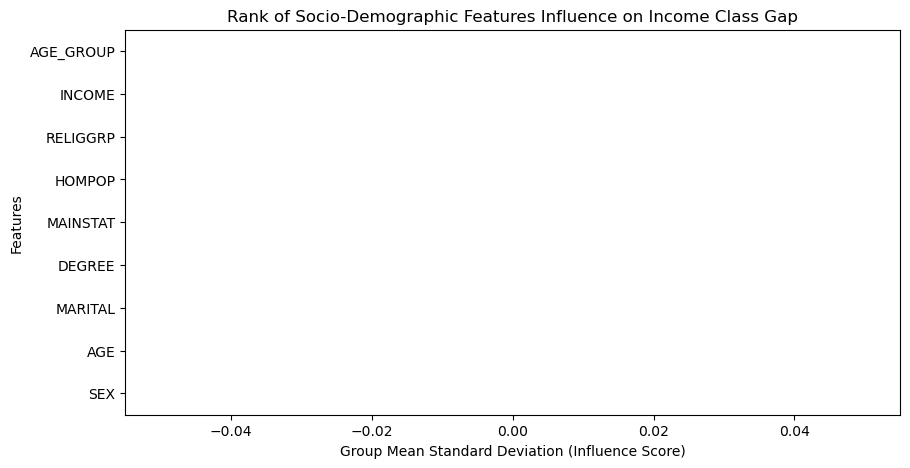

In [28]:
rank_df = pd.DataFrame(list(feat_influence.items()), columns=['Feature', 'Influence_Score'])
rank_df = rank_df.sort_values(by='Influence_Score', ascending=True)

rank_df.plot(kind='barh', x='Feature', y='Influence_Score', color='gray', legend=False, figsize=(10, 5))

plt.title('Rank of Socio-Demographic Features Influence on Income Class Gap')
plt.xlabel('Group Mean Standard Deviation (Influence Score)')
plt.ylabel('Features')
plt.show()

Correlation

convert to numerical for gap correlation

In [29]:
features = ['SEX', 'AGE', 'MARITAL', 'DEGREE', 'MAINSTAT', 'HOMPOP', 'RELIGGRP', 'INCOME', 'AGE_GROUP']
eda2_df[features + ['GAP']] = (eda2_df[features + ['GAP']].apply(pd.to_numeric, errors='coerce'))
corr_with_gap = (eda2_df[features + ['GAP']].corr(method='pearson')['GAP'].drop('GAP').dropna())

Plot

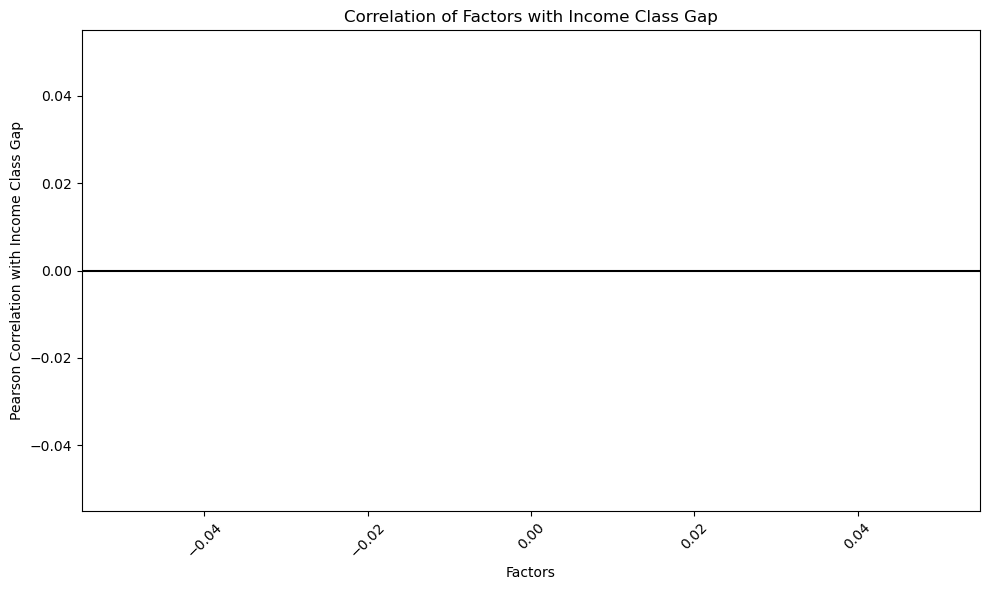

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(corr_with_gap.index, corr_with_gap.values)

for i, value in enumerate(corr_with_gap.values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center')

plt.axhline(0, color='black')
plt.xlabel('Factors')
plt.ylabel('Pearson Correlation with Income Class Gap')
plt.title('Correlation of Factors with Income Class Gap')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**EDA #3**

TypeError: Image data of dtype object cannot be converted to float

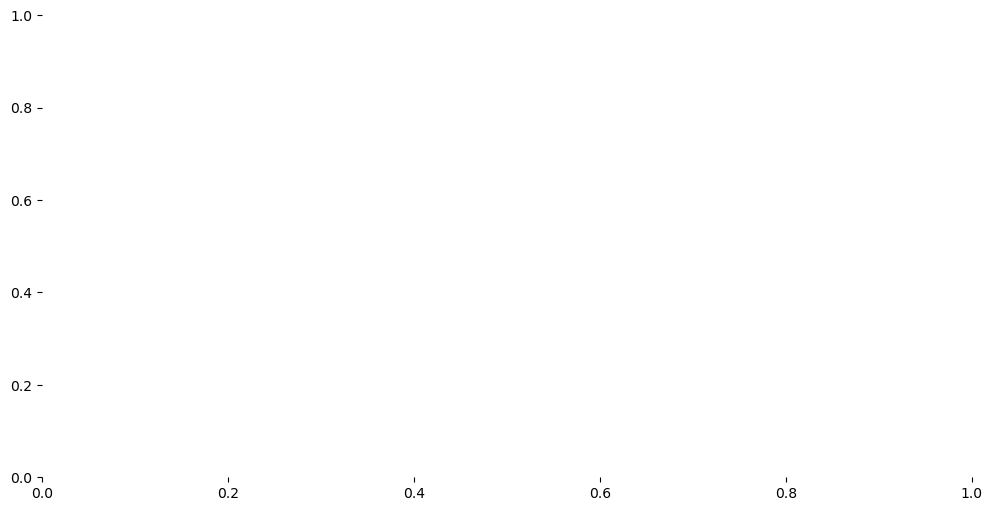

In [31]:

research_q3 = new_df.copy()


research_q3['income_class_gap'] = research_q3['TOPBOT'] - research_q3['INCOME']

clean_df = research_q3.dropna(subset=['income_class_gap', 'INCOME', 'DEGREE', 'HOMPOP', 'MAINSTAT'])


# =====================================================================
# HEATMAP 1: INCOME × DEGREE
# =====================================================================
pivot_inc_deg = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="DEGREE", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_deg,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × DEGREE Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Educational Attainment (DEGREE)")
plt.tight_layout()
plt.show()


# =====================================================================
# HEATMAP 2: INCOME × HOMPOP
# =====================================================================
pivot_inc_pop = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="HOMPOP", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_pop,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × HOMPOP Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Household Population (HOMPOP)")
plt.tight_layout()
plt.show()


# =====================================================================
# HEATMAP 3: INCOME × MAINSTAT
# =====================================================================
pivot_inc_mainstat = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="MAINSTAT", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_mainstat,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × MAINSTAT Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Main Labor Force Status (MAINSTAT)")
plt.tight_layout()
plt.show()

In [ ]:
# First, check what columns are available in your DataFrame
print("Available columns:")
print(research_q3.columns.tolist())

# Check the shape of your DataFrame to ensure it has data
print(f"\nDataFrame shape: {research_q3.shape}")

# Look for similar column names that might contain 'HOMPOP'
print("\nColumns containing 'HOMPOP' (case-insensitive):")
matching_cols = [col for col in research_q3.columns if 'hompop' in col.lower()]
print(matching_cols)

# If you find the correct column name, replace 'HOMPOP' with the actual column name
# For example, if the correct column name is found:
# research_q3['correct_column_name'].value_counts()

# Alternative: Check first few rows to see the data structure
print("\nFirst few rows:")
print(research_q3.head())

In [ ]:
research_q1['INCOME'].value_counts()

In [ ]:
new_df['INCOME'].value_counts()

In [ ]:
new_df.info()

In [ ]:
research_q1['TOPBOT'].value_counts()

In [ ]:


# =====================================================================
# STEP 1: PREPARATION AND BORROWING FEATURES
# =====================================================================
research_q3 = research_q1.copy()

# Hiramin ang Top 3 Demographics mula sa Feature Importance
research_q3['DEGREE'] = new_df['DEGREE']
research_q3['HOMPOP'] = new_df['HOMPOP']
research_q3['MAINSTAT'] = new_df['MAINSTAT']

# Compute the Gap
research_q3['income_class_gap'] = research_q3['TOPBOT'] - research_q3['INCOME']

# Linisin ang blanks para sa lahat ng gagamiting columns
clean_df = research_q3.dropna(subset=['income_class_gap', 'INCOME', 'DEGREE', 'HOMPOP', 'MAINSTAT'])


# =====================================================================
# HEATMAP 1: INCOME × DEGREE
# =====================================================================
pivot_inc_deg = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="DEGREE", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_deg,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × DEGREE Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Educational Attainment (DEGREE)")
plt.tight_layout()
plt.show()


# =====================================================================
# HEATMAP 2: INCOME × HOMPOP
# =====================================================================
pivot_inc_pop = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="HOMPOP", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_pop,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × HOMPOP Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Household Population (HOMPOP)")
plt.tight_layout()
plt.show()


# =====================================================================
# HEATMAP 3: INCOME × MAINSTAT
# =====================================================================
pivot_inc_mainstat = clean_df.pivot_table(
    values="income_class_gap", 
    index="INCOME", 
    columns="MAINSTAT", 
    aggfunc="mean",
    observed=False  # Para mawala ang warning
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_inc_mainstat,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Income-Class Gap"},
)
plt.title(
    "Magnitude and Direction of Income-Class Gap:\nINCOME × MAINSTAT Intersection",
    fontsize=14,
    pad=15,
)
plt.ylabel("Objective Income Level (INCOME)")
plt.xlabel("Main Labor Force Status (MAINSTAT)")
plt.tight_layout()
plt.show()